In [1]:
import glob, os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from xeofs.single import EOF, EOFRotator

In [5]:
data_dir = "../Data/AIRS-cropped"
files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))
print(f"Found {len(files)} monthly files")

def load_month(f):
    stamp = os.path.basename(f).replace(".nc", "")
    t = pd.to_datetime(stamp, format="%Y%m")
    ds = xr.open_dataset(f, decode_timedelta=False)
    da = ds["co_mmr_midtrop"]

    if "orbit_pass" in da.dims:
        da = da.mean("orbit_pass")
       

    da = da.squeeze(drop=True)
    da = da.reset_coords(drop=True)
    assert set(da.dims) <= {"lat", "lon", "latitude", "longitude"}, f"unexpected dims: {list(da.dims)}"
    if "latitude" in da.dims:
        da = da.rename({"latitude": "lat", "longitude": "lon"})
    return da.expand_dims(time=[t])
co = xr.concat([load_month(f) for f in files], dim="time").sortby("time")
print(co)
print(f"Record: {co.time.values[0]} to {co.time.values[-1]}, {co.sizes['time']} months")

Found 279 monthly files
<xarray.DataArray 'co_mmr_midtrop' (time: 279, lat: 36, lon: 61)> Size: 2MB
array([[[1.18725566e-07, 1.19088966e-07, 1.21251219e-07, ...,
         1.22357477e-07, 1.22225288e-07, 1.21200983e-07],
        [1.18157189e-07, 1.18775908e-07, 1.19539237e-07, ...,
         1.21974963e-07, 1.21307181e-07, 1.20940626e-07],
        [1.18503650e-07, 1.18580104e-07, 1.19185621e-07, ...,
         1.20633061e-07, 1.20899145e-07, 1.20441257e-07],
        ...,
        [1.56831419e-07, 1.55238979e-07, 1.54033643e-07, ...,
         1.45559028e-07, 1.45100856e-07, 1.45798339e-07],
        [1.56292430e-07, 1.54540430e-07, 1.56240162e-07, ...,
         1.47575378e-07, 1.47162638e-07, 1.48404311e-07],
        [1.58185259e-07, 1.57825440e-07, 1.59163164e-07, ...,
         1.47698501e-07, 1.48312580e-07, 1.49006752e-07]],

       [[1.26096097e-07, 1.26738200e-07, 1.27458776e-07, ...,
         1.24153729e-07, 1.25081911e-07, 1.25152539e-07],
        [1.27159723e-07, 1.27971873e-07, 1.28

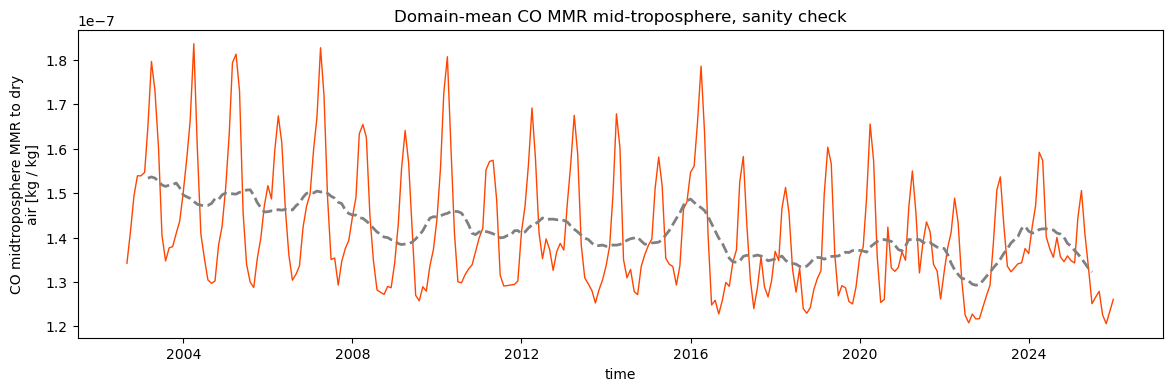

In [6]:
# domain-mean timeseries with cos(lat) weights, should reproduce your earlier plot
w = np.cos(np.deg2rad(co.lat))
ts = co.weighted(w).mean(dim=["lat", "lon"])

fig, ax = plt.subplots(figsize=(14, 4))
ts.plot(ax=ax, color="orangered", lw=1)
ts.rolling(time=12, center=True).mean().plot(ax=ax, color="gray", ls="--", lw=2)
ax.set_title("Domain-mean CO MMR mid-troposphere, sanity check")
plt.show()

In [ ]:
# remove the monthly climatology
clim = co.groupby("time.month").mean("time")
anom = (co.groupby("time.month") - clim).rename("co_anom")

# optional: remove the linear trend so leading modes are interannual rather than trend
DETREND = False
if DETREND:
    fit = anom.polyfit(dim="time", deg=1)
    anom = anom - xr.polyval(anom["time"], fit.polyfit_coefficients)

anom = anom.transpose("time", "lat", "lon")

SyntaxError: invalid syntax (1960103355.py, line 6)

In [17]:
model = EOF(n_modes=10, use_coslat=True)   # sqrt(cos(lat)) weighting handled internally
model.fit(anom, dim="time")

eofs_da = model.components()                       # (mode, lat, lon)
pcs     = model.scores()                           # (mode, time)
expvar  = model.explained_variance_ratio().values * 100

for i, v in enumerate(expvar, start=1):
    print(f"Mode {i}: {v:.1f}% of variance")

Mode 1: 64.6% of variance
Mode 2: 12.0% of variance
Mode 3: 4.5% of variance
Mode 4: 2.6% of variance
Mode 5: 2.3% of variance
Mode 6: 1.7% of variance
Mode 7: 1.4% of variance
Mode 8: 1.0% of variance
Mode 9: 0.9% of variance
Mode 10: 0.7% of variance


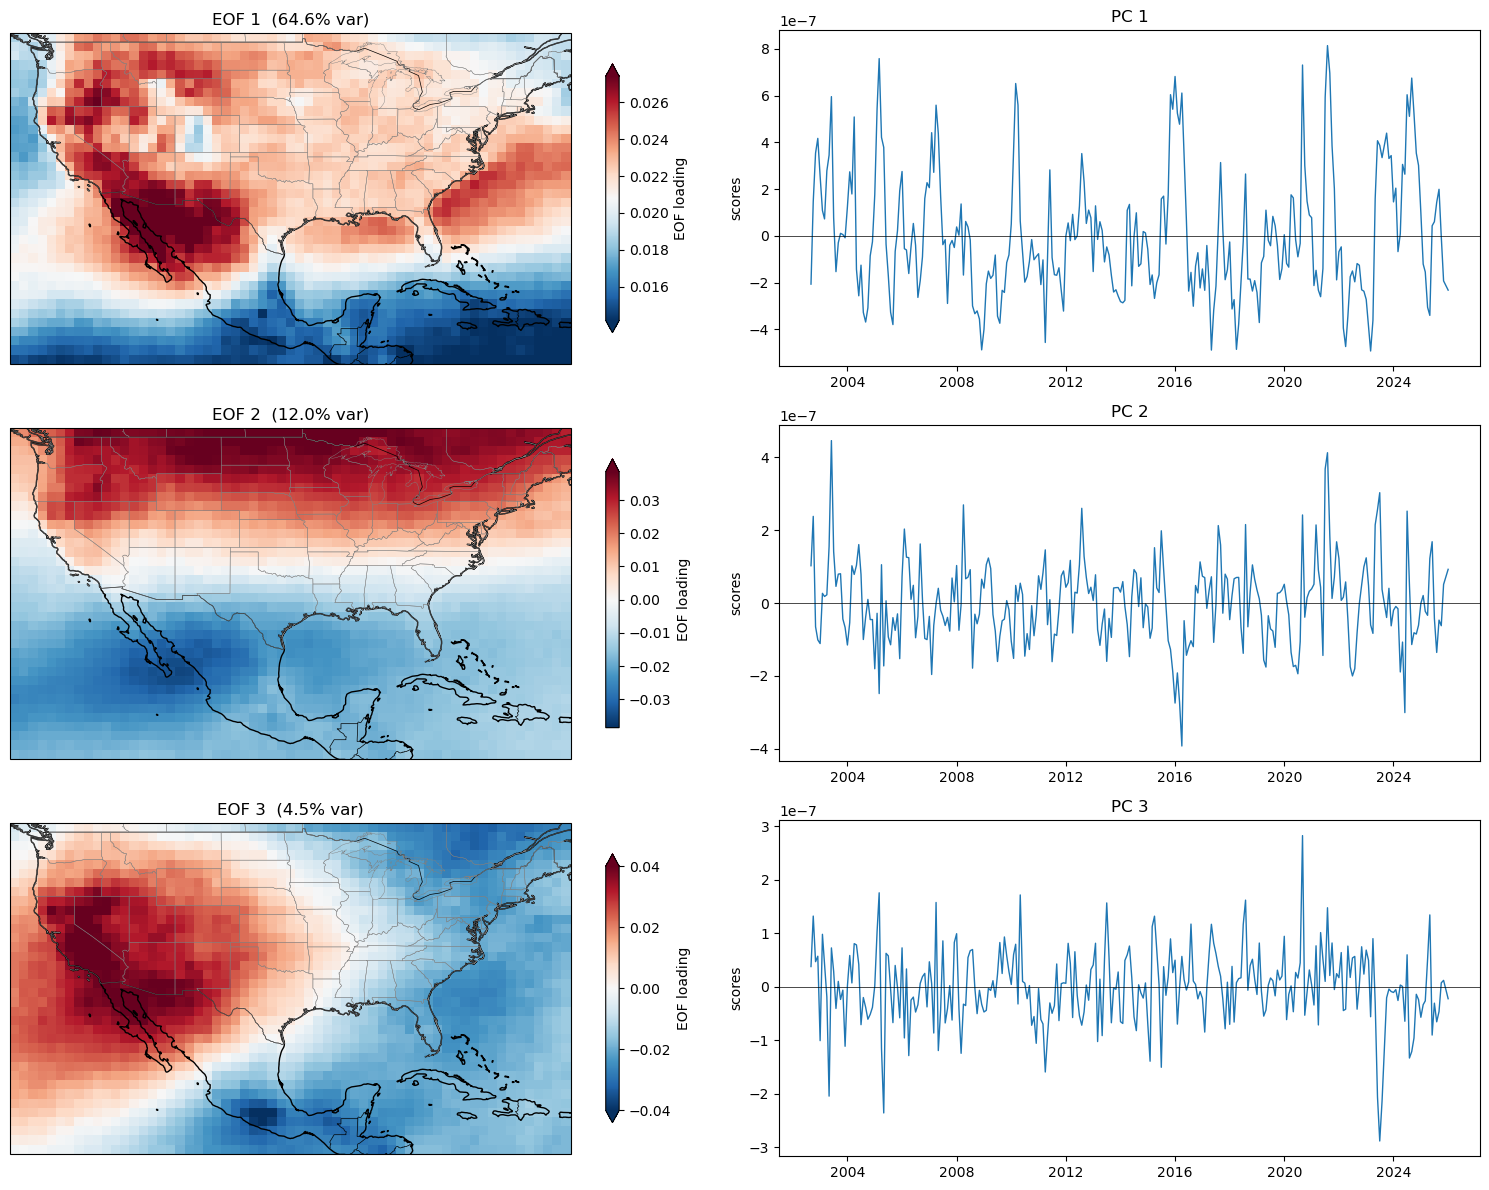

In [18]:
n_show = 3
fig = plt.figure(figsize=(15, 4 * n_show))

for i in range(n_show):
    ax_map = fig.add_subplot(n_show, 2, 2*i + 1, projection=ccrs.PlateCarree())
    eofs_da.sel(mode=i+1).plot(
        ax=ax_map, transform=ccrs.PlateCarree(),
        cmap="RdBu_r", robust=True,
        cbar_kwargs={"label": "EOF loading", "shrink": 0.8},
    )
    ax_map.coastlines()
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")
    ax_map.set_title(f"EOF {i+1}  ({expvar[i]:.1f}% var)")

    ax_pc = fig.add_subplot(n_show, 2, 2*i + 2)
    pcs.sel(mode=i+1).plot(ax=ax_pc, lw=1)
    ax_pc.axhline(0, color="k", lw=0.5)
    ax_pc.set_title(f"PC {i+1}")
    ax_pc.set_xlabel("")

plt.tight_layout()
plt.show()

## EOF on the raw data (no climatology removal, no detrending)

Same analysis as above, but applied directly to the original `co` field instead of the anomalies.

In [12]:
# run the EOF on the original data directly (no climatology, no detrend)
raw = co.transpose("time", "lat", "lon")

model_raw = EOF(n_modes=10, use_coslat=True)   # sqrt(cos(lat)) weighting handled internally
model_raw.fit(raw, dim="time")

eofs_raw = model_raw.components()                       # (mode, lat, lon)
pcs_raw  = model_raw.scores()                           # (mode, time)
expvar_raw = model_raw.explained_variance_ratio().values * 100

for i, v in enumerate(expvar_raw, start=1):
    print(f"Mode {i}: {v:.1f}% of variance")

Mode 1: 83.8% of variance
Mode 2: 6.4% of variance
Mode 3: 3.4% of variance
Mode 4: 1.1% of variance
Mode 5: 0.8% of variance
Mode 6: 0.6% of variance
Mode 7: 0.5% of variance
Mode 8: 0.4% of variance
Mode 9: 0.3% of variance
Mode 10: 0.2% of variance


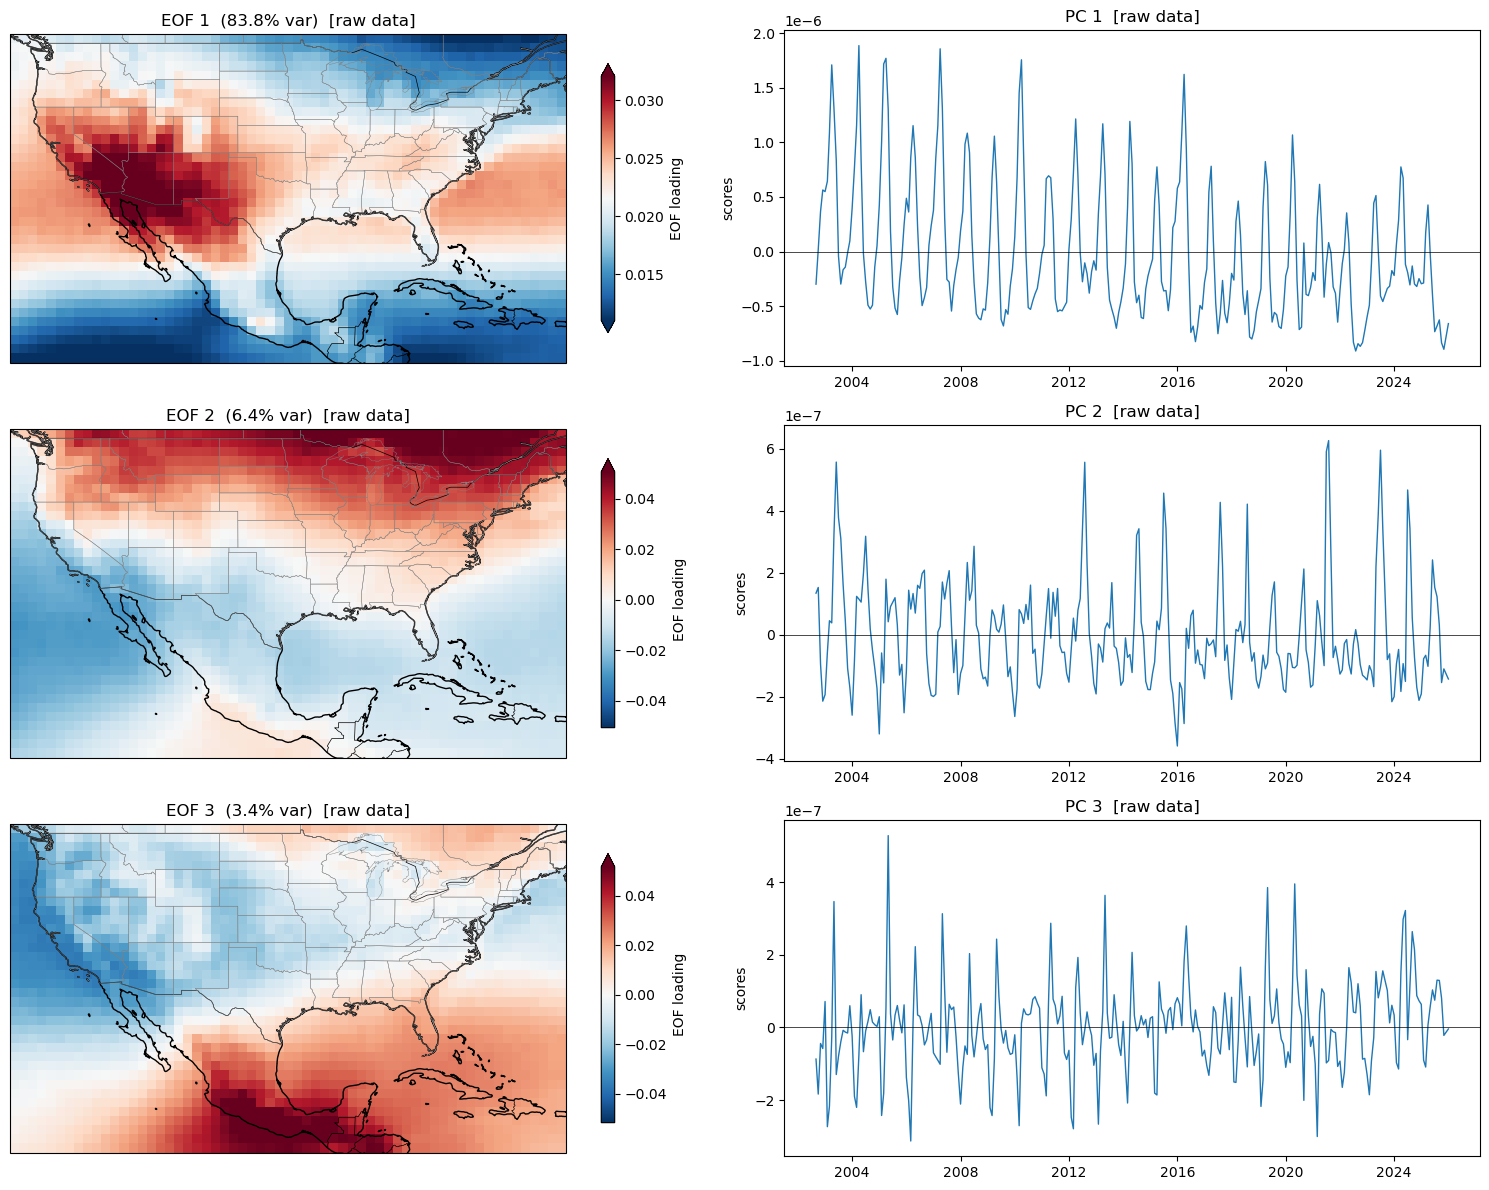

In [13]:
n_show = 3
fig = plt.figure(figsize=(15, 4 * n_show))

for i in range(n_show):
    ax_map = fig.add_subplot(n_show, 2, 2*i + 1, projection=ccrs.PlateCarree())
    eofs_raw.sel(mode=i+1).plot(
        ax=ax_map, transform=ccrs.PlateCarree(),
        cmap="RdBu_r", robust=True,
        cbar_kwargs={"label": "EOF loading", "shrink": 0.8},
    )
    ax_map.coastlines()
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")
    ax_map.set_title(f"EOF {i+1}  ({expvar_raw[i]:.1f}% var)  [raw data]")

    ax_pc = fig.add_subplot(n_show, 2, 2*i + 2)
    pcs_raw.sel(mode=i+1).plot(ax=ax_pc, lw=1)
    ax_pc.axhline(0, color="k", lw=0.5)
    ax_pc.set_title(f"PC {i+1}  [raw data]")
    ax_pc.set_xlabel("")

plt.tight_layout()
plt.show()

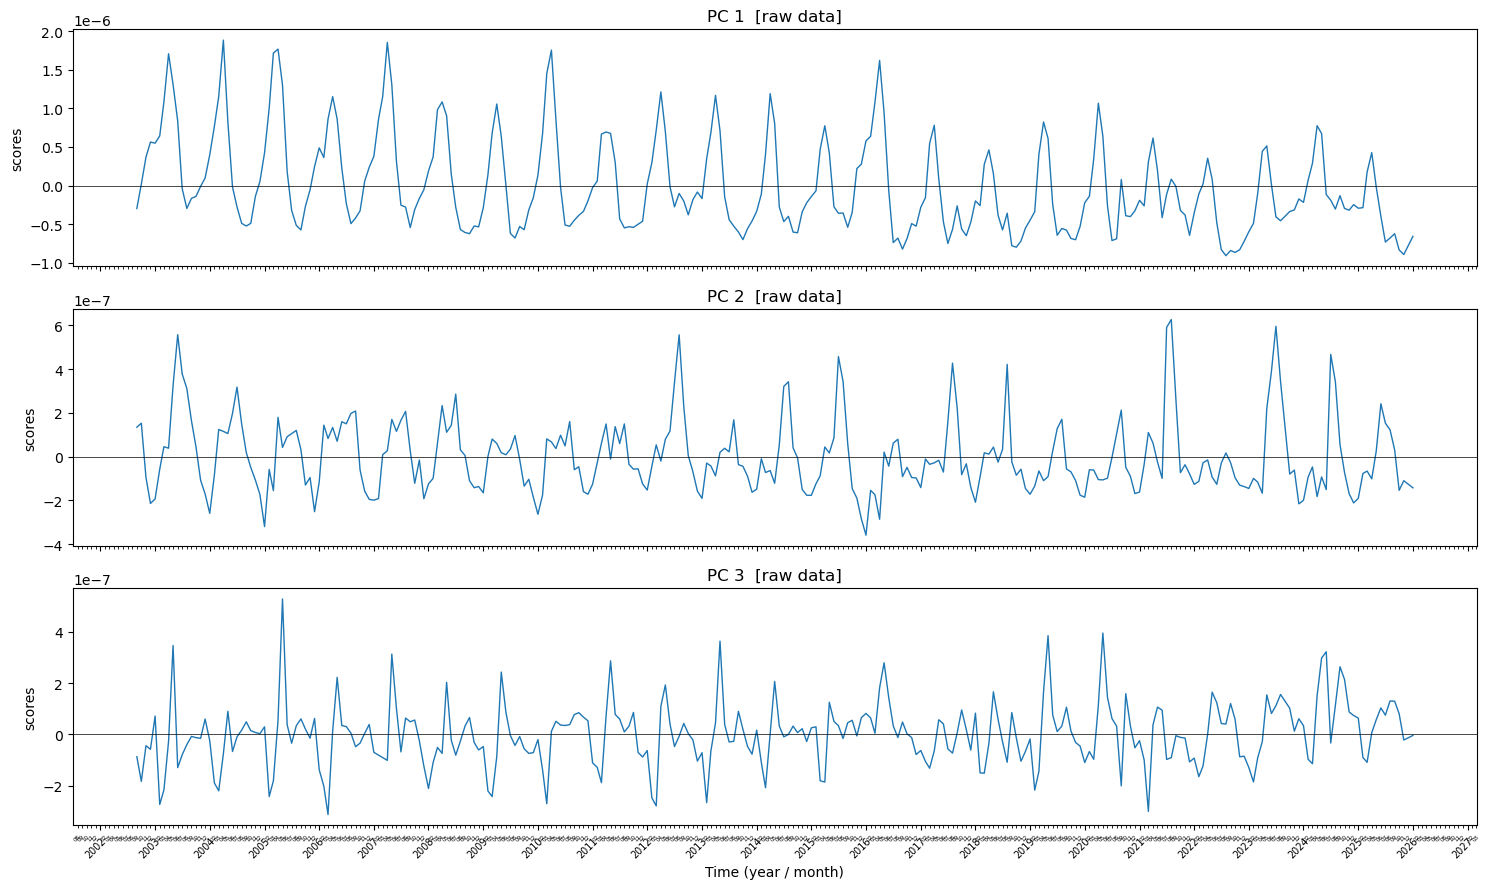

In [11]:
import matplotlib.dates as mdates

# PC time series only (raw-data EOF), with month-level ticks on the x-axis
n_show = 3
fig, axes = plt.subplots(n_show, 1, figsize=(15, 3 * n_show), sharex=True)

for i, ax in enumerate(axes):
    pcs_raw.sel(mode=i+1).plot(ax=ax, lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"PC {i+1}  [raw data]")
    ax.set_xlabel("")

    # major ticks at the start of each year, minor ticks every month
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.xaxis.set_minor_formatter(mdates.DateFormatter("%m"))
    # oblique (tilted), small tick labels
    plt.setp(ax.get_xticklabels(which="major"), rotation=45, ha="right",
             rotation_mode="anchor", fontsize=7)
    plt.setp(ax.get_xticklabels(which="minor"), rotation=45, ha="right",
             rotation_mode="anchor", fontsize=4)

axes[-1].set_xlabel("Time (year / month)")
plt.tight_layout()
plt.show()